# 03 — Analyse géographique et API `/geo`

Ce notebook construit les agrégats par wilaya, compare transactions et anomalies, produit une visualisation géographique simplifiée et tente un appel facultatif à l'API FastAPI. Il fonctionne même lorsque l'API n'est pas démarrée.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (11, 6), 'figure.dpi': 110})

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'backend' / 'src' / 'mauripay').exists():
            return candidate
    raise RuntimeError('Racine MauriPay-Analytics introuvable')

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / 'backend' / 'src'))
DATA_DIR = ROOT / 'data' / 'generated'
OUTPUT_DIR = ROOT / 'notebooks' / 'outputs' / '03_geographie'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)

## Chargement autonome du dataset
Le notebook réutilise MauriPay-M lorsqu'il existe. Sur une installation propre, il génère automatiquement les 100 000 lignes.

In [2]:
from mauripay.detection.io import load_table
from mauripay.synthetic.exporters import export_transactions
from mauripay.synthetic.generator import generate_transactions

candidates = [
    DATA_DIR / 'mauripay_m_notebook_100k.parquet',
    DATA_DIR / 'mauripay_m_100k.csv',
]
DATA_PATH = next((path for path in candidates if path.exists()), candidates[0])
if not DATA_PATH.exists():
    print('Génération de MauriPay-M pour l’analyse géographique...')
    transactions = generate_transactions(rows=100_000, seed=SEED)
    export_transactions(transactions, DATA_PATH)
    del transactions

df = load_table(DATA_PATH)
df['amount'] = pd.to_numeric(df['amount'], errors='coerce').fillna(0)
df['is_anomaly_bool'] = df['is_anomaly'].astype(str).str.lower().isin(['true', '1', 'yes'])
df['is_failed_bool'] = df['status'].astype(str).str.upper().eq('FAILED')
print(f'Dataset : {DATA_PATH.name} — {len(df):,} transactions')

Dataset : mauripay_m_notebook_100k.parquet — 100,000 transactions


## Agrégats par wilaya
Comme l'endpoint `/geo`, l'analyse considère séparément le rôle expéditeur et le rôle destinataire, puis les réunit sous une colonne `wilaya`.

In [3]:
value_columns = ['amount', 'is_anomaly_bool', 'is_failed_bool']
sender_geo = df[['sender_wilaya', *value_columns]].rename(columns={'sender_wilaya': 'wilaya'})
receiver_geo = df[['receiver_wilaya', *value_columns]].rename(columns={'receiver_wilaya': 'wilaya'})
geo_events = pd.concat([sender_geo, receiver_geo], ignore_index=True).dropna(subset=['wilaya'])
geo = (geo_events.groupby('wilaya')
       .agg(transactions=('wilaya', 'size'),
            montant_total=('amount', 'sum'),
            anomalies=('is_anomaly_bool', 'sum'),
            taux_echec=('is_failed_bool', 'mean'))
       .sort_values('transactions', ascending=False))
geo['taux_anomalie'] = geo['anomalies'] / geo['transactions']
display(geo.style.format({'montant_total': '{:,.0f}', 'taux_echec': '{:.2%}', 'taux_anomalie': '{:.2%}'}))
geo.to_csv(OUTPUT_DIR / 'agregats_par_wilaya.csv')

,transactions,montant_total,anomalies,taux_echec,taux_anomalie
wilaya,,,,,
Nouakchott-Ouest,39461,"1,271,610,555",2851,0.55%,7.22%
Nouakchott-Sud,39374,"1,238,781,813",2899,0.55%,7.36%
Nouakchott-Nord,37943,"1,208,064,729",2864,0.51%,7.55%
Dakhlet Nouadhibou,30843,"951,634,702",2504,0.49%,8.12%
Trarza,9376,"296,718,889",605,0.58%,6.45%
Brakna,8505,"251,519,126",652,0.59%,7.67%
Gorgol,6356,"193,829,633",545,0.52%,8.57%
Assaba,5877,"185,998,645",581,0.54%,9.89%
Hodh El Chargui,5516,"187,445,194",401,0.54%,7.27%


## Transactions par région

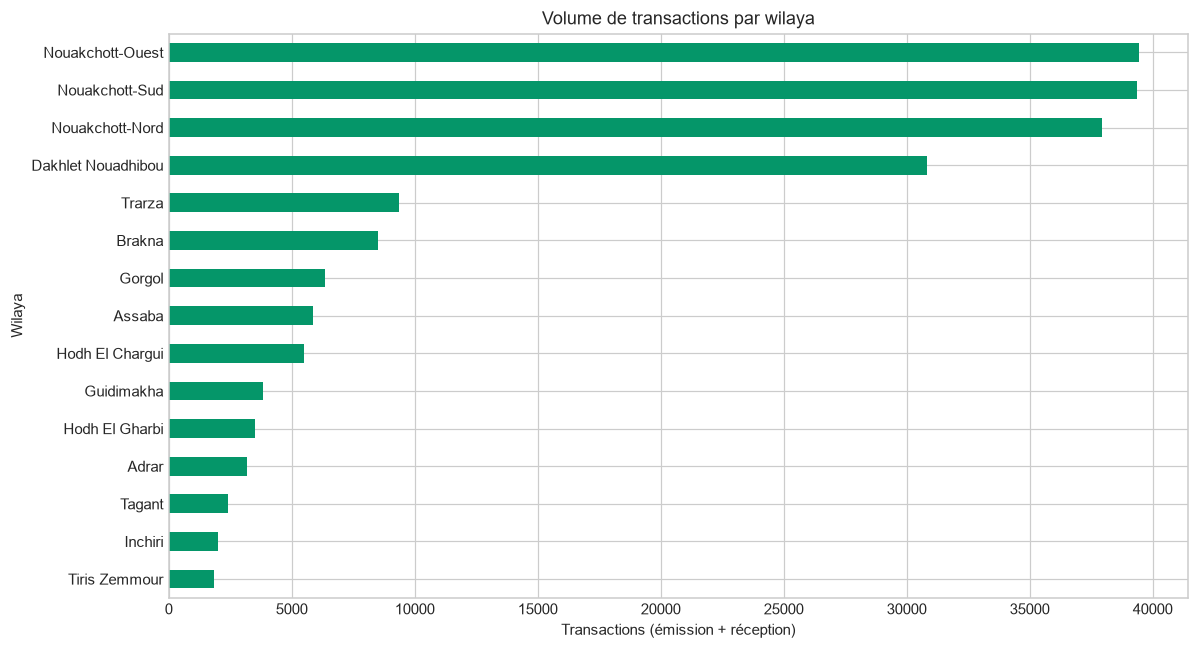

In [4]:
ax = geo.sort_values('transactions')['transactions'].plot.barh(color='#059669', title='Volume de transactions par wilaya')
ax.set(xlabel='Transactions (émission + réception)', ylabel='Wilaya')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'transactions_par_wilaya.png', bbox_inches='tight')
plt.show()

## Anomalies par wilaya
Le volume brut et le taux répondent à deux questions différentes : où trouve-t-on le plus d'alertes, et où les alertes représentent-elles la plus grande part de l'activité ?

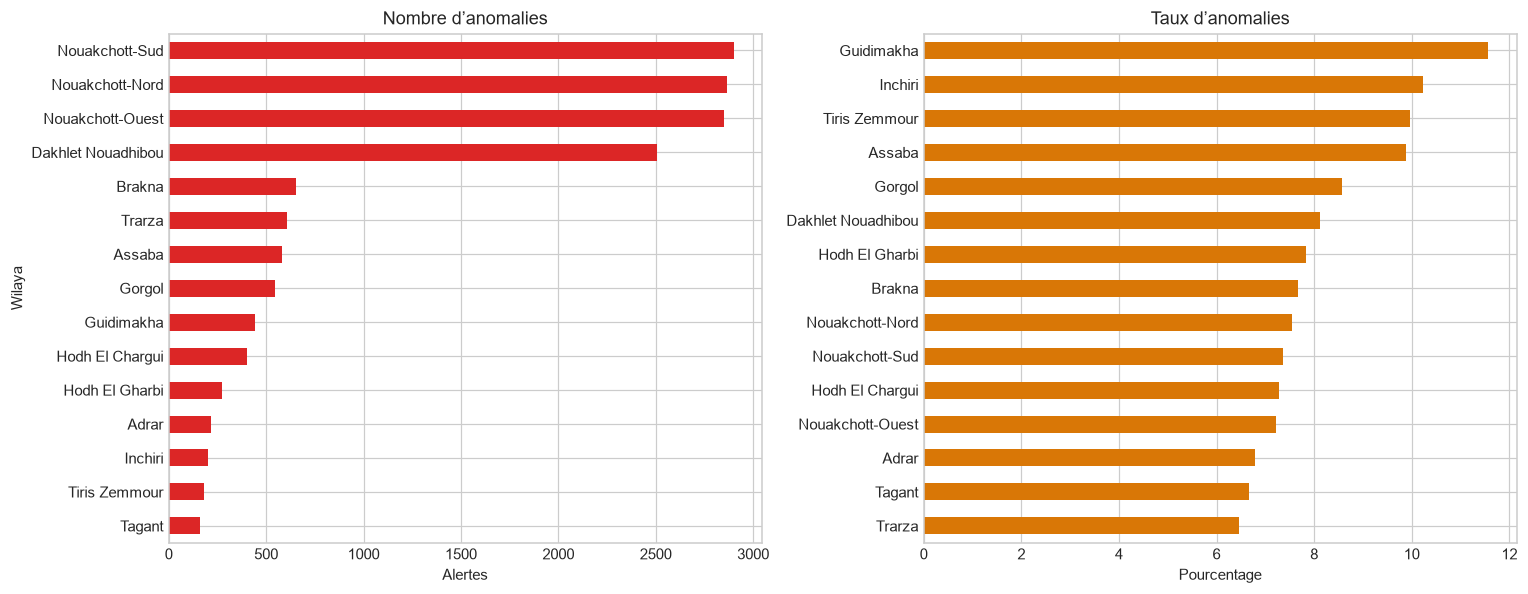

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
geo.sort_values('anomalies')['anomalies'].plot.barh(ax=axes[0], color='#dc2626', title='Nombre d’anomalies')
(geo.sort_values('taux_anomalie')['taux_anomalie'] * 100).plot.barh(ax=axes[1], color='#d97706', title='Taux d’anomalies')
axes[0].set(xlabel='Alertes', ylabel='Wilaya')
axes[1].set(xlabel='Pourcentage', ylabel='')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'anomalies_par_wilaya.png', bbox_inches='tight')
plt.show()

## Visualisation géographique simplifiée
Les points utilisent les centres administratifs approximatifs définis par le projet. Cette figure sert à l'analyse exploratoire, pas au routage ni à la localisation GPS.

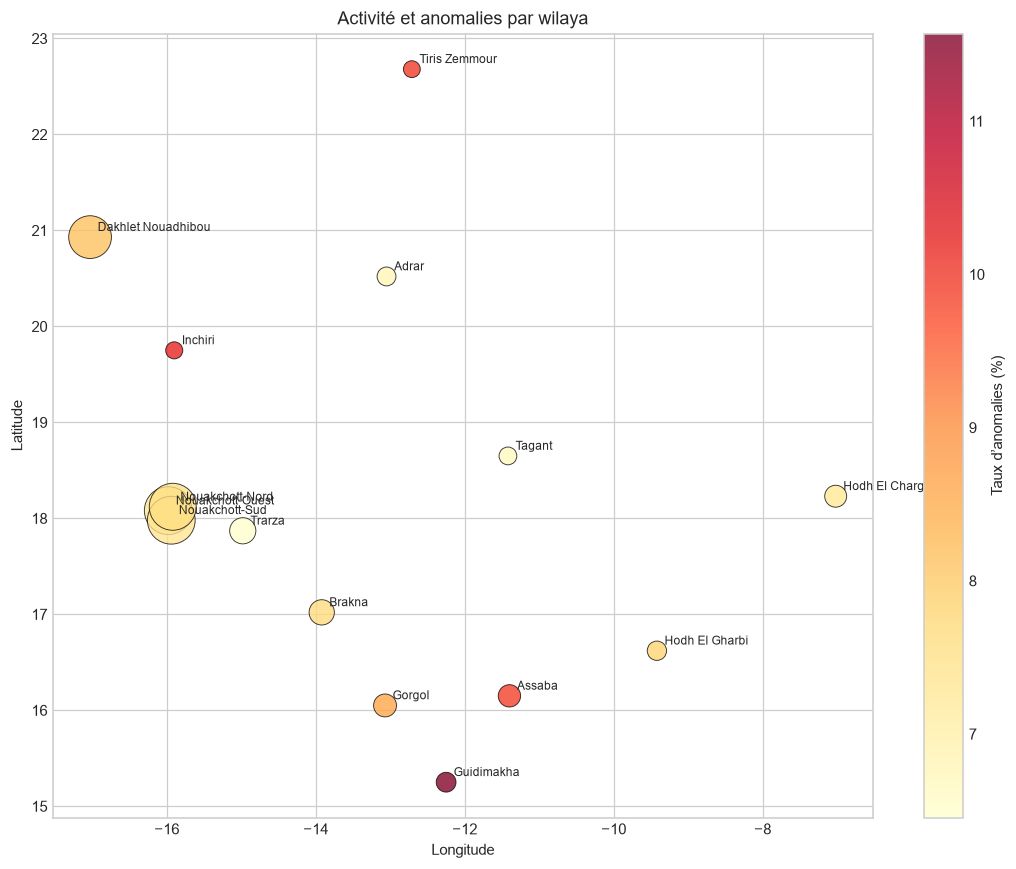

In [6]:
from mauripay.features.geographic import WILAYA_COORDINATES

map_df = geo.reset_index()
map_df['latitude'] = map_df['wilaya'].map(lambda x: WILAYA_COORDINATES.get(x, (np.nan, np.nan))[0])
map_df['longitude'] = map_df['wilaya'].map(lambda x: WILAYA_COORDINATES.get(x, (np.nan, np.nan))[1])
map_df = map_df.dropna(subset=['latitude', 'longitude'])
sizes = 80 + 900 * map_df['transactions'] / map_df['transactions'].max()
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(map_df['longitude'], map_df['latitude'], s=sizes, c=map_df['taux_anomalie'] * 100, cmap='YlOrRd', alpha=.78, edgecolor='black', linewidth=.6)
for row in map_df.itertuples():
    ax.annotate(row.wilaya, (row.longitude, row.latitude), xytext=(5, 4), textcoords='offset points', fontsize=8)
colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label('Taux d’anomalies (%)')
ax.set(title='Activité et anomalies par wilaya', xlabel='Longitude', ylabel='Latitude')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'carte_anomalies_wilayas.png', bbox_inches='tight', dpi=180)
plt.show()

## Appel facultatif de l'API `/geo`
La cellule ne bloque pas le notebook si FastAPI n'est pas démarré. Pour comparer les résultats, lancer `uvicorn mauripay.api.main:app --reload` depuis un autre terminal.

In [7]:
import httpx

api_url = 'http://127.0.0.1:8000/geo'
relative_path = DATA_PATH.relative_to(ROOT).as_posix()
try:
    response = httpx.get(api_url, params={'dataset_path': relative_path}, timeout=5.0)
    response.raise_for_status()
    api_geo = pd.DataFrame(response.json()['wilayas']).set_index('wilaya')
    print(f'API accessible : {len(api_geo)} wilayas reçues.')
    display(api_geo.head())
except (httpx.HTTPError, KeyError, ValueError) as exc:
    print(f'API non disponible — analyse locale conservée ({type(exc).__name__}).')

print(f'Figures et tableau exportés dans : {OUTPUT_DIR}')

API non disponible — analyse locale conservée (ConnectError).
Figures et tableau exportés dans : D:\mauripay-analytics\notebooks\outputs\03_geographie


## Conclusion
La géographie est un signal de contexte : une wilaya éloignée ou un taux d'alertes élevé justifie une investigation, mais ne constitue pas à elle seule une preuve de fraude. Les volumes doivent toujours être rapprochés du taux d'anomalies et du comportement historique.